In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import math
import joblib
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os
import pandas as pd
import numpy as np
from datetime import datetime
import re
import warnings
warnings.filterwarnings('ignore', category=UserWarning, message='Parsing.*in DD/MM/YYYY format')
# warnings.filterwarnings('ignore')  # Suppress all warnings

In [4]:
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_colwidth', None) # Show full column content

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, classification_report, confusion_matrix)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

import warnings
warnings.filterwarnings('ignore')

### LOAD CLEAN DATA

In [6]:
from pathlib import Path
ROOT = Path.cwd().parent 
CLEAN_FILE = ROOT / "data" / "cleaned_EMI_dataset.csv"
OUTPUT_DIR = ROOT / "data"

In [7]:
print(f"📥 Loading cleaned dataset: {CLEAN_FILE}")
df = pd.read_csv(CLEAN_FILE)
print(f"Initial shape: {df.shape}")

📥 Loading cleaned dataset: c:\Users\malay chand\Desktop\project\guvi_project\emi\EMIPredict_AI\data\cleaned_EMI_dataset.csv
Initial shape: (404800, 27)


###  DERIVED FEATURES

In [8]:
df["debt_to_income"] = df["current_emi_amount"] / df["monthly_salary"].replace(0, np.nan)

expense_cols = [
    "school_fees", "college_fees", "travel_expenses", "groceries_utilities",
    "other_monthly_expenses", "monthly_rent"
]
df["total_monthly_expenses"] = df[expense_cols].sum(axis=1)
df["expense_to_income"] = df["total_monthly_expenses"] / df["monthly_salary"].replace(0, np.nan)
df["monthly_disposable"] = (
    df["monthly_salary"] - df["total_monthly_expenses"] - df["current_emi_amount"]
)
df["instalment_if_approved"] = df["requested_amount"] / df["requested_tenure"].replace(0, np.nan)
df["affordability_ratio"] = df["monthly_disposable"] / df["instalment_if_approved"].replace(0, np.nan)
df["employment_stability"] = df["years_of_employment"] / df["age"].replace(0, np.nan)
df["loan_to_income_ratio"] = df["requested_amount"] / df["monthly_salary"].replace(0, np.nan)
df["dependents_ratio"] = df["dependents"] / df["family_size"].replace(0, np.nan)

# Clean infinities
df.replace([np.inf, -np.inf], np.nan, inplace=True)

### Load & Inspect Target Columns

In [9]:
print("=== Data Types ===")
print(df.dtypes)
print("\n=== EMI Eligibility Classes ===")
print(df['emi_eligibility'].value_counts())


=== Data Types ===
age                         int64
gender                     object
marital_status             object
education                  object
monthly_salary            float64
employment_type            object
years_of_employment       float64
company_type               object
house_type                 object
monthly_rent              float64
family_size                 int64
dependents                  int64
school_fees               float64
college_fees              float64
travel_expenses           float64
groceries_utilities       float64
other_monthly_expenses    float64
existing_loans             object
current_emi_amount        float64
credit_score              float64
bank_balance              float64
emergency_fund            float64
emi_scenario               object
requested_amount          float64
requested_tenure          float64
emi_eligibility            object
max_monthly_emi           float64
debt_to_income            float64
total_monthly_expenses    flo

### Preprocessing

In [10]:
X = df.drop(columns=['emi_eligibility', 'max_monthly_emi'])
y_class = df['emi_eligibility']
y_reg = df['max_monthly_emi']

In [11]:
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical features:", categorical_cols)
print("Numerical features:", numerical_cols)

Categorical features: ['gender', 'marital_status', 'education', 'employment_type', 'company_type', 'house_type', 'existing_loans', 'emi_scenario']
Numerical features: ['age', 'monthly_salary', 'years_of_employment', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'requested_amount', 'requested_tenure', 'debt_to_income', 'total_monthly_expenses', 'expense_to_income', 'monthly_disposable', 'instalment_if_approved', 'affordability_ratio', 'employment_stability', 'loan_to_income_ratio', 'dependents_ratio']


In [12]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

### Encode categorical variables

In [13]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)


In [14]:
label_enc = LabelEncoder()
y_train_c_enc = label_enc.fit_transform(y_train_c)
y_test_c_enc = label_enc.transform(y_test_c)


### Classification Models

In [15]:
class_models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest Classifier": RandomForestClassifier(random_state=42),
    "XGBoost Classifier": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

In [16]:
results_class = []

for name, model in class_models.items():
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', model)])
    clf.fit(X_train_c, y_train_c_enc)
    y_pred_enc = clf.predict(X_test_c)
    y_pred = label_enc.inverse_transform(y_pred_enc)
    
    acc = accuracy_score(y_test_c, y_pred)
    prec = precision_score(y_test_c, y_pred, average='weighted')
    rec = recall_score(y_test_c, y_pred, average='weighted')
    f1 = f1_score(y_test_c, y_pred, average='weighted')
    
    results_class.append([name, acc, prec, rec, f1])
    print(f"\n=== {name} ===")
    print(classification_report(y_test_c, y_pred))



=== Logistic Regression ===
              precision    recall  f1-score   support

    Eligible       0.83      0.88      0.85     14889
   High_Risk       0.00      0.00      0.00      3497
Not_Eligible       0.94      0.98      0.96     62574

    accuracy                           0.92     80960
   macro avg       0.59      0.62      0.60     80960
weighted avg       0.88      0.92      0.90     80960


=== Random Forest Classifier ===
              precision    recall  f1-score   support

    Eligible       0.89      0.90      0.89     14889
   High_Risk       0.69      0.02      0.05      3497
Not_Eligible       0.94      0.99      0.97     62574

    accuracy                           0.93     80960
   macro avg       0.84      0.64      0.64     80960
weighted avg       0.92      0.93      0.91     80960


=== XGBoost Classifier ===
              precision    recall  f1-score   support

    Eligible       0.91      0.97      0.94     14889
   High_Risk       0.73      0.18     

In [18]:
df_results_class = pd.DataFrame(results_class, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
print("\n=== Classification Model Comparison ===")
display(df_results_class.sort_values(by='F1 Score', ascending=False))


=== Classification Model Comparison ===


,Model,Accuracy,Precision,Recall,F1 Score
2,XGBoost Classifier,0.954076,0.946901,0.954076,0.943238
1,Random Forest Classifier,0.931374,0.920810,0.931374,0.912367
3,Decision Tree,0.897159,0.899443,0.897159,0.898280
0,Logistic Regression,0.916230,0.876974,0.916230,0.896160


### REGRESSION MODELS

In [19]:
reg_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "XGBoost Regressor": XGBRegressor(random_state=42),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42)
}


In [20]:
results_reg = []

for name, model in reg_models.items():
    reg = Pipeline(steps=[('preprocessor', preprocessor),
                          ('regressor', model)])
    reg.fit(X_train_r, y_train_r)
    y_pred = reg.predict(X_test_r)
    
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    mae = mean_absolute_error(y_test_r, y_pred)
    r2 = r2_score(y_test_r, y_pred)
    mape = np.mean(np.abs((y_test_r - y_pred) / y_test_r)) * 100
    
    results_reg.append([name, rmse, mae, r2, mape])
    print(f"\n=== {name} ===")
    print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.4f}, MAPE: {mape:.2f}%")


=== Linear Regression ===
RMSE: 4036.25, MAE: 2827.71, R²: 0.7240, MAPE: 198.91%

=== Random Forest Regressor ===
RMSE: 1402.26, MAE: 652.61, R²: 0.9667, MAPE: 17.20%

=== XGBoost Regressor ===
RMSE: 1366.97, MAE: 784.88, R²: 0.9683, MAPE: 41.08%

=== Decision Tree Regressor ===
RMSE: 2118.55, MAE: 1007.75, R²: 0.9240, MAPE: 21.84%


In [21]:
# Regression results summary
df_results_reg = pd.DataFrame(results_reg, columns=['Model', 'RMSE', 'MAE', 'R2', 'MAPE'])
print("\n=== Regression Model Comparison ===")
display(df_results_reg.sort_values(by='R2', ascending=False))


=== Regression Model Comparison ===


,Model,RMSE,MAE,R2,MAPE
2,XGBoost Regressor,1366.972197,784.882946,0.968348,41.084778
1,Random Forest Regressor,1402.256170,652.611107,0.966693,17.196701
3,Decision Tree Regressor,2118.550933,1007.747662,0.923975,21.836725
0,Linear Regression,4036.254168,2827.712500,0.724046,198.914561


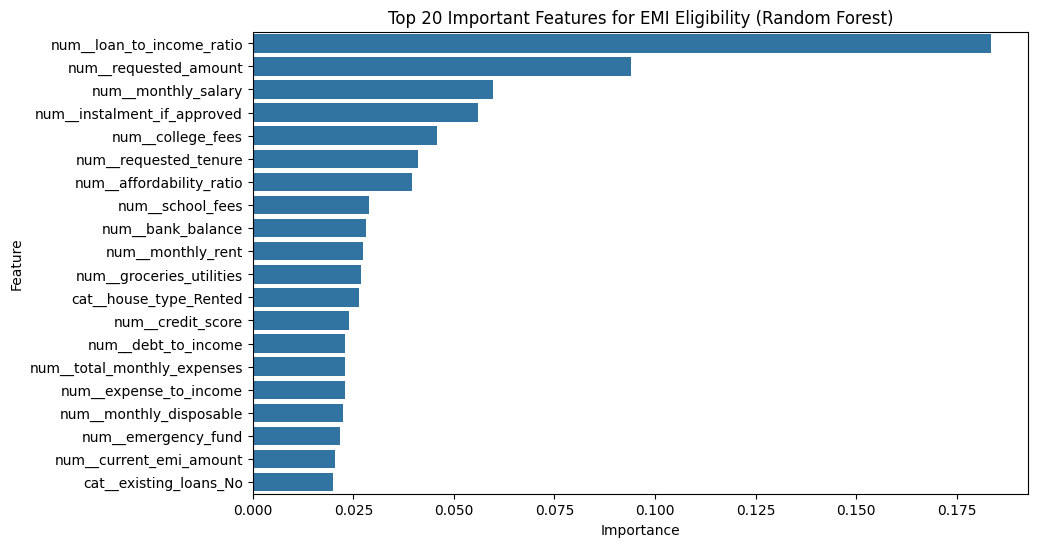

In [22]:
# ==============================
# Step 8: Feature Importance (Example using Random Forest)
# ==============================
rf_clf = Pipeline(steps=[('preprocessor', preprocessor),
                         ('classifier', RandomForestClassifier(random_state=42))])
rf_clf.fit(X_train_c, y_train_c)

# Extract feature names after one-hot encoding
encoded_features = rf_clf.named_steps['preprocessor'].get_feature_names_out()
importances = rf_clf.named_steps['classifier'].feature_importances_
feature_importance_df = pd.DataFrame({'Feature': encoded_features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Top 20 Important Features for EMI Eligibility (Random Forest)')
plt.show()